In [ ]:
import numpy as np

def randomize_actuators_simple(
    N,
    min_val=4.0,
    max_val=8.0,
    edge_strength=0.7,
    straight_tol=0.15,
    max_resample=20,
    seed=None
):
    """
    Edge-biased actuator sampling while avoiding cases where both
    actuator groups are straight.

    straight_tol:
        How close values must be to be considered "straight"

    max_resample:
        Safety cap to avoid infinite loops
    """

    if seed is not None:
        np.random.seed(seed)

    #Use edge strength to determine how much it will put on the edges
    alpha = max(0.05, 1.0 - 0.95 * edge_strength)

    results = np.zeros((N, 6))

    def is_straight(group):
        return np.std(group) < straight_tol

    for i in range(N):

        for j in range(max_resample):

            #Generate using beta distribution
            x = np.random.beta(alpha, alpha, size=6)
            vec = min_val + x * (max_val - min_val)

            g1 = vec[:3]
            g2 = vec[3:]

            # Reject if groups are straight - boring
            if not (is_straight(g1) and is_straight(g2)):
                results[i] = vec
                break
        else:
            # If we failed resampling, just accept last sample
            results[i] = vec

    return np.round(results, 2)

In [3]:
poses = randomize_actuators_simple(
    1,
    min_val=4.0,
    max_val=8.0,
    edge_strength=0.8,
    straight_tol=0.5,
    max_resample=20,
    seed=None
)

print(poses)


[[8.   8.   4.1  7.42 7.99 7.91]]


In [4]:
def gen_transform_python(
    L_k1, L_k2, L_k3,
    r,
    act_1_start,
    act_2_start,
    act_3_start,
    T_prev
):

    L_ck = (L_k1 + L_k2 + L_k3)/3

    beta_k = 2*np.sqrt(
        L_k1**2 + L_k2**2 + L_k3**2
        - L_k1*L_k2 - L_k1*L_k3 - L_k2*L_k3
    )/(3*r)

    theta_k = np.arctan2(
        3*(L_k2-L_k3),
        np.sqrt(3)*(L_k2+L_k3-2*L_k1)
    )

    rho_k = beta_k/L_ck if abs(L_ck) > 1e-8 else 0

    ct = np.cos(theta_k)
    st = np.sin(theta_k)
    cb = np.cos(beta_k)
    sb = np.sin(beta_k)

    R_k = np.array([
        [cb*ct**2 + st**2, (cb-1)*ct*st, ct*sb],
        [(cb-1)*ct*st, ct**2 + cb*st**2, st*sb],
        [-ct*sb, -st*sb, cb]
    ])

    if abs(rho_k) < 1e-6:
        P_k = np.array([0,0,L_ck])
    else:
        P_k = (1/rho_k)*np.array([
            (1-cb)*ct,
            (1-cb)*st,
            sb
        ])

    T_k = np.eye(4)
    T_k[:3,:3] = R_k
    T_k[:3,3] = P_k

    if abs(rho_k) < 1e-6:
        T_k = np.array([
            [1,0,0,0],
            [0,1,0,0],
            [0,0,1,L_ck],
            [0,0,0,1]
        ])

    a1 = T_prev @ T_k @ act_1_start
    a2 = T_prev @ T_k @ act_2_start
    a3 = T_prev @ T_k @ act_3_start

    return T_k, a1, a2, a3


In [5]:
def visualize_configuration_full(ax, q, r_real):

    act_11_start = np.array([r_real, 0, 0, 1])
    act_12_start = np.array([
        r_real*np.cos(2*np.pi/3),
        r_real*np.sin(2*np.pi/3),
        0, 1
    ])
    act_13_start = np.array([
        r_real*np.cos(4*np.pi/3),
        r_real*np.sin(4*np.pi/3),
        0, 1
    ])

    Base_coord = np.eye(4)
    prev_T = Base_coord.copy()

    num_segments = len(q)//3
    from scipy.interpolate import CubicSpline

    centers = [Base_coord[:3,3]]
    actuator_pts = [[act_11_start[:3]],
                    [act_12_start[:3]],
                    [act_13_start[:3]]]

    for seg in range(num_segments):

        idx = seg*3

        T_k, a1, a2, a3 = gen_transform_python(
            q[idx], q[idx+1], q[idx+2],
            r_real,
            act_11_start,
            act_12_start,
            act_13_start,
            prev_T
        )

        prev_T = prev_T @ T_k
        centers.append(prev_T[:3,3])

        actuator_pts[0].append(a1[:3])
        actuator_pts[1].append(a2[:3])
        actuator_pts[2].append(a3[:3])

    centers = np.array(centers).T

    # centers shape should be (3, N)
    from scipy.interpolate import CubicSpline

    # centers shape (3,N)
    centers_pts = centers

    # arc length parameterization
    t = np.zeros(centers_pts.shape[1])
    for i in range(1, len(t)):
        t[i] = t[i-1] + np.linalg.norm(centers_pts[:,i] - centers_pts[:,i-1])

    tt = np.linspace(0, t[-1], 200)

    # enforce first segment vertical: dx/ds=0, dy/ds=0, dz/ds=1
    cs_x = CubicSpline(t, centers_pts[0], bc_type=((1,0.0), 'natural'))
    cs_y = CubicSpline(t, centers_pts[1], bc_type=((1,0.0), 'natural'))
    cs_z = CubicSpline(t, centers_pts[2], bc_type=((1,1.0), 'natural'))

    xx = cs_x(tt)
    yy = cs_y(tt)
    zz = cs_z(tt)

    ax.plot(xx, yy, zz, '--', linewidth=1.5)
    from scipy.interpolate import CubicSpline

    # ---- Plot actuator splines ----
    colors = ['r','g','b']

    for act in range(3):
        pts = np.array(actuator_pts[act]).T   # shape (3, N)

        # Arc length parameterization (same as MATLAB)
        t = np.zeros(pts.shape[1])
        for i in range(1, len(t)):
            t[i] = t[i-1] + np.linalg.norm(pts[:,i] - pts[:,i-1])

        if t[-1] < 1e-8:
            continue

        tt = np.linspace(0, t[-1], 150)

        cs_x = CubicSpline(t, pts[0])
        cs_y = CubicSpline(t, pts[1])
        cs_z = CubicSpline(t, pts[2])

        xx = cs_x(tt)
        yy = cs_y(tt)
        zz = cs_z(tt)

        #ax.plot(xx, yy, zz, colors[act], linewidth=1)

    # ---- Cross Section Circles ----
    num_sections = len(actuator_pts[0])

    for seg in range(num_sections):

        P1 = actuator_pts[0][seg]
        P2 = actuator_pts[1][seg]
        P3 = actuator_pts[2][seg]

        P1 = np.array(P1)
        P2 = np.array(P2)
        P3 = np.array(P3)

        normal = np.cross(P2-P1, P3-P1)

        if np.linalg.norm(normal) < 1e-6:
            normal = np.array([0,0,1])
        else:
            normal = normal / np.linalg.norm(normal)

        center = (P1 + P2 + P3) / 3

        radius = np.mean([
            np.linalg.norm(P1-center),
            np.linalg.norm(P2-center),
            np.linalg.norm(P3-center)
        ])

        v1 = P1 - center
        v1 = v1 / np.linalg.norm(v1)

        v2 = np.cross(normal, v1)
        v2 = v2 / np.linalg.norm(v2)

        theta = np.linspace(0, 2*np.pi, 80)

        circle = center.reshape(3,1) + radius*(np.outer(v1,np.cos(theta)) + np.outer(v2,np.sin(theta)))

        #ax.plot(circle[0], circle[1], circle[2], 'k', linewidth=1)

        # markers
        #ax.plot([P1[0]],[P1[1]],[P1[2]],'ro',markersize=3)
        #ax.plot([P2[0]],[P2[1]],[P2[2]],'go',markersize=3)
        #ax.plot([P3[0]],[P3[1]],[P3[2]],'bo',markersize=3)


In [6]:
import numpy as np
import matplotlib.pyplot as plt


def plot_vine_robot_sets(q_flat, n, r_real=None):

    if r_real is None:
        r_real = 5 * 2 / np.pi / 2

    q_flat = np.array(q_flat)

    values_per_config = 3 * n
    if len(q_flat) % values_per_config != 0:
        raise ValueError("Invalid q length")

    num_configs = len(q_flat) // values_per_config

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.set_xlim([-10, 10])
    ax.set_ylim([-10, 10])
    ax.set_zlim([0, 10])
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    for i in range(num_configs):
        q = q_flat[i*values_per_config:(i+1)*values_per_config]
        visualize_configuration_full(ax, q, r_real)

    plt.show()



4.5,5.9,4.5,4.8,5.68,5.99
4.54,5.87,4.99,5.74,4.85,4.51
5.83,4.55,4.56,5.16,5.97,5.87
5.17,5.94,4.51,5.58,4.82,4.62
4.64,5.93,5.85,5.63,5.97,5.71
4.94,4.52,5.99,4.67,4.76,5.99
4.92,5.27,5.97,6.0,4.5,5.89
4.6,4.77,5.98,5.71,6.0,4.55
5.49,4.86,4.84,5.87,5.59,4.53
5.96,5.36,4.51,5.23,4.52,4.5
6.0,4.52,4.6,4.51,6.0,4.61
5.49,4.51,5.98,4.5,5.68,6.0
5.92,5.89,5.74,5.46,6.0,4.77
5.98,5.71,4.5,4.79,5.24,4.57
4.5,5.67,5.06,4.51,5.25,5.87
5.99,6.0,4.56,5.97,4.79,5.62
6.0,4.81,6.0,5.99,4.59,4.51
4.59,4.75,5.49,5.65,4.52,6.0
5.92,4.85,5.09,5.75,4.53,4.66
6.0,5.46,4.56,5.35,5.51,4.91
5.89,4.51,5.32,4.57,4.51,5.98
5.79,5.8,6.0,5.93,4.57,4.86
5.56,5.34,4.5,4.51,5.82,5.08
5.94,4.51,4.5,4.62,5.89,5.23
5.3,4.5,5.89,5.01,4.56,4.55
5.98,5.05,5.5,4.5,5.43,5.99
5.78,5.76,4.5,4.95,4.53,4.53
5.98,5.94,5.23,4.56,5.87,4.54
6.0,5.85,4.6,5.32,4.5,4.57
4.5,5.83,4.6,5.94,4.54,5.65
4.67,5.42,5.82,5.97,4.59,5.71
4.5,5.02,4.5,4.73,5.67,5.97
5.07,4.53,4.85,4.6,6.0,6.0
4.53,5.99,4.6,5.66,5.73,4.5
6.0,5.82,5.17,6.0,4.77

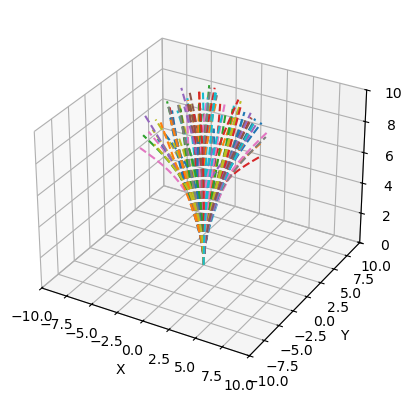

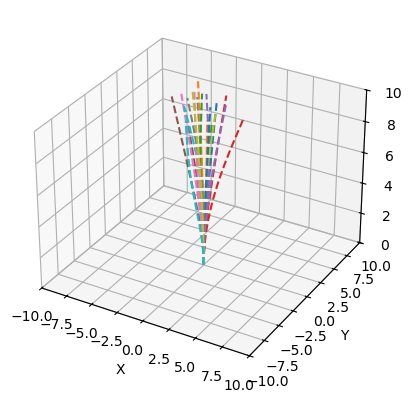

In [7]:
poses2 = randomize_actuators_simple(
    100,
    min_val=4.5,
    max_val=6.0,
    edge_strength=0.7,
    straight_tol=0.5,
    max_resample=20,
    seed=None
)

#print(poses)
#print(poses2)
for i in range(poses2.shape[0]):
    #print(poses2[i,:])
    print()
    for j in range(poses2.shape[1]):
        print(poses2[i,j],end="")
        if j == 5:
            pass
        else:
            print(",", end="")
poses3 = np.random.uniform(4.6,6,[20,6])
#print(poses3)
flattened_arr = poses2.flatten()
plot_vine_robot_sets(q_flat=flattened_arr, n=2, r_real=1.5)
flattened_arr = poses3.flatten()
plot_vine_robot_sets(q_flat=flattened_arr, n=2, r_real=1.5)

In [15]:
data_str = """""
4.5,5.9,4.5,4.8,5.68,5.99
4.54,5.87,4.99,5.74,4.85,4.51
5.83,4.55,4.56,5.16,5.97,5.87
5.17,5.94,4.51,5.58,4.82,4.62
4.64,5.93,5.85,5.63,5.97,5.71
4.94,4.52,5.99,4.67,4.76,5.99
4.92,5.27,5.97,6.0,4.5,5.89
4.6,4.77,5.98,5.71,6.0,4.55
5.49,4.86,4.84,5.87,5.59,4.53
5.96,5.36,4.51,5.23,4.52,4.5
6.0,4.52,4.6,4.51,6.0,4.61
5.49,4.51,5.98,4.5,5.68,6.0
5.92,5.89,5.74,5.46,6.0,4.77
5.98,5.71,4.5,4.79,5.24,4.57
4.5,5.67,5.06,4.51,5.25,5.87
5.99,6.0,4.56,5.97,4.79,5.62
6.0,4.81,6.0,5.99,4.59,4.51
4.59,4.75,5.49,5.65,4.52,6.0
5.92,4.85,5.09,5.75,4.53,4.66
6.0,5.46,4.56,5.35,5.51,4.91
5.89,4.51,5.32,4.57,4.51,5.98
5.79,5.8,6.0,5.93,4.57,4.86
5.56,5.34,4.5,4.51,5.82,5.08
5.94,4.51,4.5,4.62,5.89,5.23
5.3,4.5,5.89,5.01,4.56,4.55
5.98,5.05,5.5,4.5,5.43,5.99
5.78,5.76,4.5,4.95,4.53,4.53
5.98,5.94,5.23,4.56,5.87,4.54
6.0,5.85,4.6,5.32,4.5,4.57
4.5,5.83,4.6,5.94,4.54,5.65
4.67,5.42,5.82,5.97,4.59,5.71
4.5,5.02,4.5,4.73,5.67,5.97
5.07,4.53,4.85,4.6,6.0,6.0
4.53,5.99,4.6,5.66,5.73,4.5
6.0,5.82,5.17,6.0,4.77,5.99
4.94,6.0,4.5,5.84,5.93,4.5
5.96,4.51,5.94,5.98,4.96,5.98
4.53,4.52,5.54,6.0,4.5,4.99
5.95,5.67,6.0,4.5,5.98,5.87
4.56,5.99,6.0,5.99,4.88,4.51
4.5,5.78,4.52,4.66,4.63,5.87
4.71,5.88,5.77,4.52,4.6,6.0
4.5,5.22,5.53,6.0,5.65,4.68
4.5,5.61,5.93,4.5,6.0,6.0
4.62,4.5,5.57,4.81,5.94,6.0
4.76,5.98,5.99,5.84,5.5,5.6
6.0,5.07,5.9,4.5,6.0,4.68
6.0,4.77,5.33,5.04,5.76,4.82
6.0,4.71,5.63,5.27,4.5,4.7
6.0,5.93,4.5,4.76,6.0,5.88
4.54,5.99,4.5,4.9,5.12,5.78
5.98,5.56,4.51,5.13,6.0,5.46
4.78,6.0,4.51,5.64,4.7,4.61
5.51,6.0,4.52,4.55,6.0,5.99
6.0,4.5,5.24,5.92,5.74,6.0
5.13,4.84,4.59,5.96,5.46,4.56
4.53,6.0,6.0,4.93,4.51,6.0
4.73,5.95,5.99,5.11,4.5,4.56
5.26,4.53,5.35,4.88,4.86,6.0
5.93,6.0,5.0,4.81,4.53,5.77
5.95,4.53,5.55,4.5,6.0,5.43
4.5,5.87,5.5,4.51,5.43,5.99
5.98,5.9,4.5,5.71,5.53,4.56
5.27,4.79,5.79,5.32,5.97,4.53
5.97,5.72,5.89,5.33,4.5,5.99
4.92,5.14,4.89,5.21,4.58,5.82
5.99,5.69,5.93,4.63,5.8,6.0
4.5,5.98,5.5,4.57,5.99,4.54
4.81,6.0,4.52,5.61,5.16,5.74
5.83,6.0,4.5,4.66,4.5,5.58
5.69,5.05,5.98,6.0,4.59,5.97
5.88,5.77,4.51,4.58,5.99,4.81
5.55,4.5,4.54,4.5,5.65,5.97
5.96,5.83,5.12,4.6,5.88,5.99
4.62,4.57,5.94,4.5,6.0,5.97
6.0,5.89,4.55,5.5,4.56,4.57
4.5,6.0,4.69,4.57,5.96,5.55
6.0,5.9,5.59,5.13,5.99,4.64
4.89,6.0,4.59,4.73,4.5,4.61
5.61,5.91,4.54,4.95,5.0,6.0
4.5,5.99,4.62,5.99,5.33,4.54
6.0,4.5,5.59,4.86,5.86,5.99
5.99,4.57,5.22,5.61,4.51,6.0
4.66,6.0,4.5,5.43,4.57,6.0
4.77,5.96,5.88,5.96,5.94,5.89
4.5,5.98,4.65,4.93,5.24,4.5
4.53,4.54,5.64,4.61,5.38,5.82
4.67,5.97,6.0,5.48,4.54,5.98
5.44,4.51,5.69,4.5,4.52,5.03
4.63,6.0,5.84,5.81,5.71,5.83
5.02,4.51,6.0,4.5,5.57,4.52
5.66,4.54,5.84,5.24,5.93,5.03
4.83,4.51,5.74,5.68,5.36,5.99
6.0,5.98,4.51,5.27,4.93,5.96
4.5,5.75,5.86,5.05,4.5,4.75
4.52,5.85,4.53,5.43,5.92,4.65
5.26,5.85,4.56,4.5,4.58,5.71
5.75,4.87,4.5,5.69,5.97,4.77
5.57,4.5,6.0,5.84,4.8,5.17
5.5,5.93,5.78,4.51,4.78,6.0"""

In [ ]:
import io
# Converting to a NumPy array

lines = data_str.strip().split('\n')

data_list = [line.split(',') for line in lines if line.strip()]

data_list = [row for row in data_list if len(row) == 6]


data_array = np.array(data_list, dtype=float)

print(f"Shape: {data_array.shape}")

print(data_array[0])

Success! Shape: (100, 6)
[4.5  5.9  4.5  4.8  5.68 5.99]
